# Phase 5 — Training Loop

In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import pandas as pd
import sys

# Setup paths
sys.path.append(os.path.abspath("../src"))
from dataset import create_dataloaders
from model import IntentClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: mps


In [2]:
# Define configuration
config = {
  "seed": 42,
  "embed_dim": 128,
  "hidden_size": 256,
  "num_layers": 1,
  "bidirectional": True,
  "dropout": 0.3,
  "batch_size": 32,
  "learning_rate": 0.001,
  "max_epochs": 30,
  "early_stopping_patience": 5,
}

# Set seed
torch.manual_seed(config["seed"])

# Load metadata from Phase 2
with open("../data/processed/metadata.json", "r") as f:
    metadata = json.load(f)
    
config["vocab_size"] = metadata["vocab_size"]
config["max_seq_len"] = metadata["max_seq_len"]

# Save config
exp_dir = "../experiments/exp_002_bidirectional"
os.makedirs(exp_dir, exist_ok=True)
with open(os.path.join(exp_dir, "config.json"), "w") as f:
    json.dump(config, f, indent=2)
print("Config saved!")


Config saved!


In [3]:
# Load Data
with open("../data/processed/word2idx.json", "r") as f:
    word2idx = json.load(f)
with open("../data/processed/idx2label.json", "r") as f:
    idx2label = {int(k): v for k, v in json.load(f).items()}
label2idx = {v: k for k, v in idx2label.items()}

train_loader, val_loader, _, _ = create_dataloaders(
    train_dir="../data/raw/train",
    val_dir="../data/raw/test",
    word2idx=word2idx,
    label2idx=label2idx,
    max_seq_len=config["max_seq_len"],
    batch_size=config["batch_size"]
)
print("DataLoaders ready.")


DataLoaders ready.


In [4]:
# Initialize model
model = IntentClassifier(
    vocab_size=config["vocab_size"],
    embed_dim=config["embed_dim"],
    hidden_size=config["hidden_size"],
    num_layers=config["num_layers"],
    num_classes=len(label2idx),
    dropout=config["dropout"],
    bidirectional=config["bidirectional"],
    pad_idx=word2idx.get("<PAD>", 0)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print(model)


IntentClassifier(
  (embedding): Embedding(4000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=7, bias=True)
)


In [5]:
# Training Loop
best_val_accuracy = 0.0
epochs_no_improve = 0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

os.makedirs("../models", exist_ok=True)

for epoch in range(1, config["max_epochs"] + 1):
    # --- TRAINING ---
    model.train()
    total_loss, correct, total = 0, 0, 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        
        optimizer.zero_grad()
        logits = model(texts)
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    
    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for texts, labels in val_loader:
            texts, labels = texts.to(device), labels.to(device)
            logits = model(texts)
            loss = criterion(logits, labels)
            
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    # Update scheduler
    scheduler.step(val_acc)
    
    print(f"Epoch {epoch}/{config['max_epochs']} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    # Checkpointing
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        epochs_no_improve = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_accuracy': val_acc,
            'hyperparameters': config
        }, "../models/best_model.pt")
        print("  -> Saved new best model!")
    else:
        epochs_no_improve += 1
        
    # Early Stopping
    if epochs_no_improve >= config["early_stopping_patience"]:
        print(f"Early stopping triggered at epoch {epoch}")
        break

print(f"\nTraining complete! Best Validation Accuracy: {best_val_accuracy*100:.2f}%")


Epoch 1/30 | Train Loss: 0.2222 | Train Acc: 93.86% | Val Loss: 0.1064 | Val Acc: 96.71%
  -> Saved new best model!


Epoch 2/30 | Train Loss: 0.0605 | Train Acc: 98.11% | Val Loss: 0.0702 | Val Acc: 97.57%
  -> Saved new best model!


Epoch 3/30 | Train Loss: 0.0314 | Train Acc: 99.07% | Val Loss: 0.0470 | Val Acc: 98.00%
  -> Saved new best model!


Epoch 4/30 | Train Loss: 0.0212 | Train Acc: 99.35% | Val Loss: 0.0754 | Val Acc: 97.71%


Epoch 5/30 | Train Loss: 0.0168 | Train Acc: 99.53% | Val Loss: 0.0838 | Val Acc: 97.57%


...

Epoch 14/30 | Train Loss: 0.0024 | Train Acc: 99.92% | Val Loss: 0.0880 | Val Acc: 98.00%


Epoch 15/30 | Train Loss: 0.0085 | Train Acc: 99.76% | Val Loss: 0.0897 | Val Acc: 98.29%


Epoch 16/30 | Train Loss: 0.0037 | Train Acc: 99.90% | Val Loss: 0.0995 | Val Acc: 98.14%


Epoch 17/30 | Train Loss: 0.0015 | Train Acc: 99.96% | Val Loss: 0.1016 | Val Acc: 98.43%


Epoch 18/30 | Train Loss: 0.0014 | Train Acc: 99.95% | Val Loss: 0.1023 | Val Acc: 98.43%
Early stopping triggered at epoch 18

Training complete! Best Validation Accuracy: 98.57%


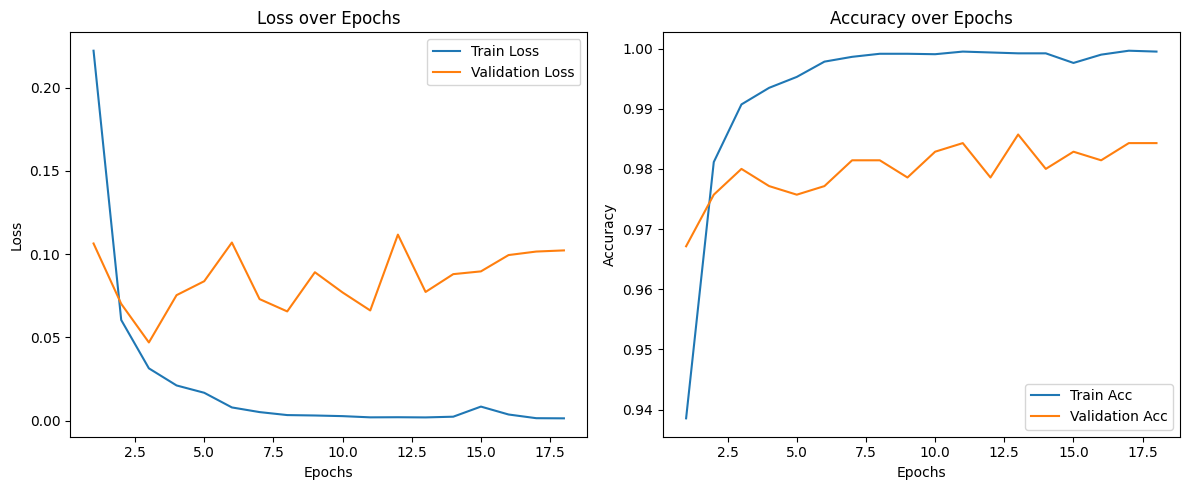

In [6]:
# Plotting
import matplotlib.pyplot as plt

os.makedirs("../assets", exist_ok=True)

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label='Train Loss')
plt.plot(epochs, history["val_loss"], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label='Train Acc')
plt.plot(epochs, history["val_acc"], label='Validation Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig("../assets/training_curves.png")
plt.show()

# Save history
pd.DataFrame(history).to_csv(os.path.join(exp_dir, "training_log.csv"), index=False)
